In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
# import data
eco_perform = pd.read_csv('../data/Zambia_EconomicPerformance/eco_perform.csv')

In [4]:
ep_clean, ep_lookup = clean_wb_wide(eco_perform)

In [5]:
ep_lookup
# series_lookup.loc[series_lookup['Series Code'] == 'NY.GDP.MKTP.KD.ZG']

,Series Code,Series Name
0,NY.GDP.MKTP.KD,GDP (constant 2015 US$)
1,NY.GDP.DEFL.ZS,GDP deflator (base year varies by country)
2,NY.GDP.MKTP.KD.ZG,GDP growth (annual %)
3,NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$)
4,NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 internation..."
5,NY.GDP.PCAP.KD.ZG,GDP per capita growth (annual %)
6,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (..."
7,SL.UEM.TOTL.NE.ZS,"Unemployment, total (% of total labor force) (..."
8,SL.UEM.ADVN.ZS,Unemployment with advanced education (% of tot...
9,SL.UEM.BASC.ZS,Unemployment with basic education (% of total ...


In [6]:
latex = ep_lookup.to_latex(
    index=False,
    escape=True,
    column_format='lp{10cm}',
    caption='World Bank indicators used in Economic Performance (Zambia)',
    label='tab:eco_perform_indicator_list'
)

print(latex)

\begin{table}
\caption{World Bank indicators used in Economic Performance (Zambia)}
\label{tab:eco_perform_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
NY.GDP.MKTP.KD & GDP (constant 2015 US\$) \\
NY.GDP.DEFL.ZS & GDP deflator (base year varies by country) \\
NY.GDP.MKTP.KD.ZG & GDP growth (annual \%) \\
NY.GDP.PCAP.KD & GDP per capita (constant 2015 US\$) \\
NY.GDP.PCAP.PP.KD & GDP per capita, PPP (constant 2021 international \$) \\
NY.GDP.PCAP.KD.ZG & GDP per capita growth (annual \%) \\
SL.UEM.TOTL.ZS & Unemployment, total (\% of total labor force) (modeled ILO estimate) \\
SL.UEM.TOTL.NE.ZS & Unemployment, total (\% of total labor force) (national estimate) \\
SL.UEM.ADVN.ZS & Unemployment with advanced education (\% of total labor force with advanced education) \\
SL.UEM.BASC.ZS & Unemployment with basic education (\% of total labor force with basic education) \\
SL.UEM.INTM.ZS & Unemployment with intermediate education (\% of total labo

# Check data availability by series and year

In [7]:
ep_summary = summary_wb(ep_clean, ep_lookup)
ep_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,NY.GDP.MKTP.KD,GDP (constant 2015 US$),0.000000,65,1960,2024
1,NY.GDP.DEFL.ZS,GDP deflator (base year varies by country),0.000000,65,1960,2024
2,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),1.538462,64,1961,2024
3,NY.GDP.PCAP.KD,GDP per capita (constant 2015 US$),0.000000,65,1960,2024
4,NY.GDP.PCAP.PP.KD,"GDP per capita, PPP (constant 2021 internation...",46.153846,35,1990,2024
5,NY.GDP.PCAP.KD.ZG,GDP per capita growth (annual %),1.538462,64,1961,2024
6,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",47.692308,34,1991,2024
7,SL.UEM.TOTL.NE.ZS,"Unemployment, total (% of total labor force) (...",70.769231,19,1986,2023
8,SL.UEM.ADVN.ZS,Unemployment with advanced education (% of tot...,87.692308,8,2015,2023
9,SL.UEM.BASC.ZS,Unemployment with basic education (% of total ...,87.692308,8,2015,2023


In [10]:
summary_latex = ep_summary.drop(columns=['Series Name']).copy()

summary_latex['missing_pct'] = summary_latex['missing_pct'].round(1)

summary_latex = summary_latex.rename(columns={
    'Series Code': 'Series Code',
    'Series Name': 'Series Name',
    'missing_pct': 'Missing (\\%)',
    'n_obs': 'Obs.',
    'first_year': 'First year',
    'last_year': 'Last year'
})

print(
    summary_latex.to_latex(
        index=False,
        escape=True,
        float_format="%.2f",
        caption='Data availability of Economic Performance (Zambia)',
        label='tab:data_availability_eco_perform'
    )
)

\begin{table}
\caption{Data availability of Economic Performance (Zambia)}
\label{tab:data_availability_eco_perform}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
NY.GDP.MKTP.KD.ZG & 1.50 & 64 & 1961 & 2024 \\
NY.GDP.PCAP.KD & 0.00 & 65 & 1960 & 2024 \\
NY.GDP.PCAP.PP.KD & 46.20 & 35 & 1990 & 2024 \\
NY.GDP.PCAP.KD.ZG & 1.50 & 64 & 1961 & 2024 \\
SL.UEM.TOTL.ZS & 47.70 & 34 & 1991 & 2024 \\
SL.UEM.TOTL.NE.ZS & 70.80 & 19 & 1986 & 2023 \\
SL.UEM.ADVN.ZS & 87.70 & 8 & 2015 & 2023 \\
SL.UEM.BASC.ZS & 87.70 & 8 & 2015 & 2023 \\
SL.UEM.INTM.ZS & 87.70 & 8 & 2015 & 2023 \\
SL.UEM.TOTL.FE.ZS & 47.70 & 34 & 1991 & 2024 \\
SL.UEM.TOTL.FE.NE.ZS & 75.40 & 16 & 1986 & 2023 \\
SL.UEM.TOTL.MA.ZS & 47.70 & 34 & 1991 & 2024 \\
SL.UEM.TOTL.MA.NE.ZS & 75.40 & 16 & 1986 & 2023 \\
\bottomrule
\end{tabular}
\end{table}



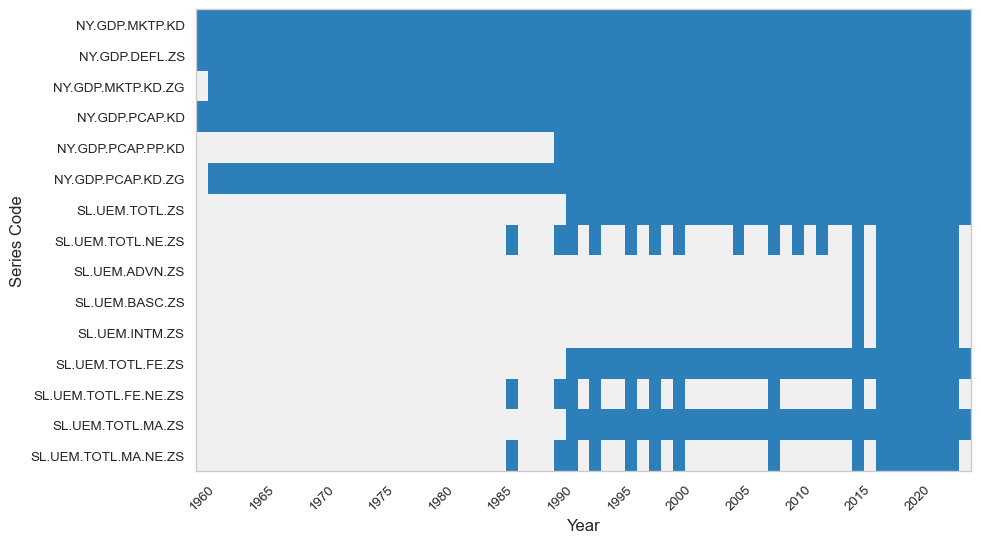

In [8]:
availability, fig, ax = plot_missing_heatmap(
    ep_clean,
    lookup=ep_lookup
)

fig.savefig(
    "../figures/eco_performance/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

# GDP

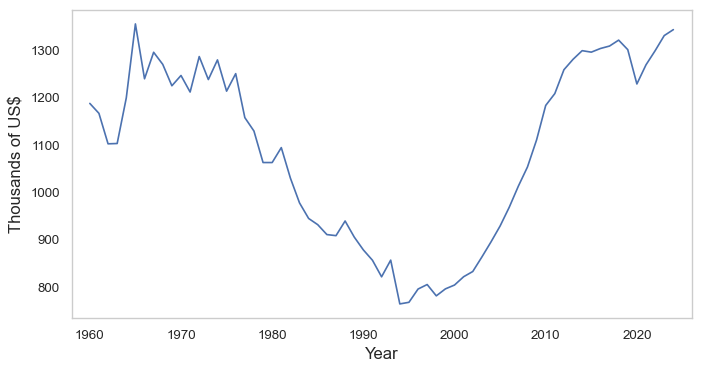

In [9]:
df = eco_perform_clean.dropna(subset=['NY.GDP.PCAP.KD'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Year'], df['NY.GDP.PCAP.KD'])
# ax.set_title('GDP per capita (constant 2015 US$)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Thousands of US$', fontsize=12)

# set range
# ax.set_ylim(700, 4000)
ax.set_xlim(1958, 2026)
ax.grid(False)

fig.savefig(
    "../figures/eco_performance/GDPPC_overall.pdf",
    format="pdf",
    bbox_inches="tight"
)

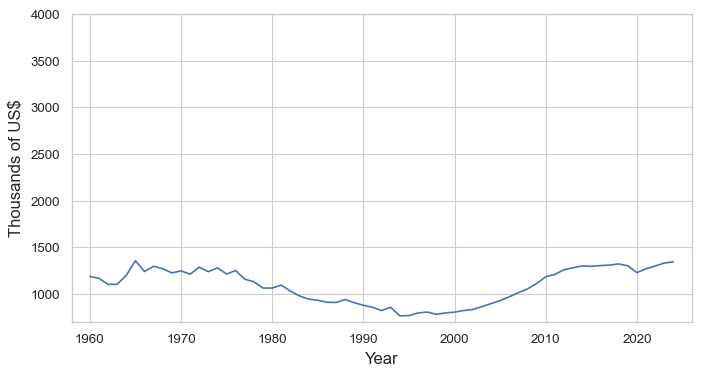

In [10]:
df = eco_perform_clean.dropna(subset=['NY.GDP.PCAP.KD'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Year'], df['NY.GDP.PCAP.KD'])
# ax.set_title('GDP per capita (constant 2015 US$)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Thousands of US$', fontsize=12)

# set range
ax.set_ylim(700, 4000)
ax.set_xlim(1958, 2026)

fig.savefig(
    "../figures/eco_performance/GDPPC_constant.pdf",
    format="pdf",
    bbox_inches="tight"
)

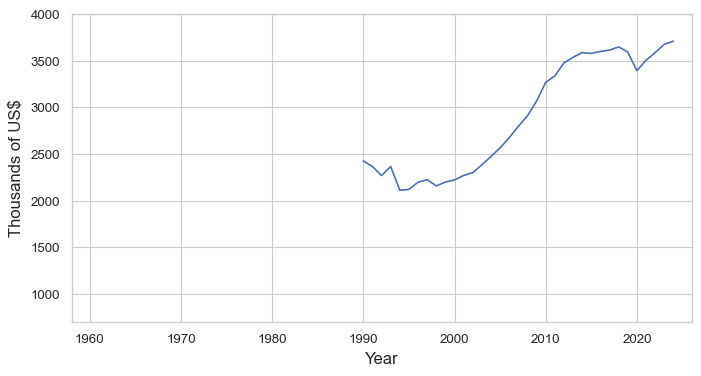

In [11]:
df = eco_perform_clean.dropna(subset=['NY.GDP.PCAP.PP.KD'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Year'], df['NY.GDP.PCAP.PP.KD'])
# ax.set_title('GDP per capita, PPP (constant 2021 international $)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Thousands of US$', fontsize=12)

# set range
ax.set_ylim(700, 4000)
ax.set_xlim(1958, 2026)

fig.savefig(
    "../figures/eco_performance/GDPPC_PPP.pdf",
    format="pdf",
    bbox_inches="tight"
)

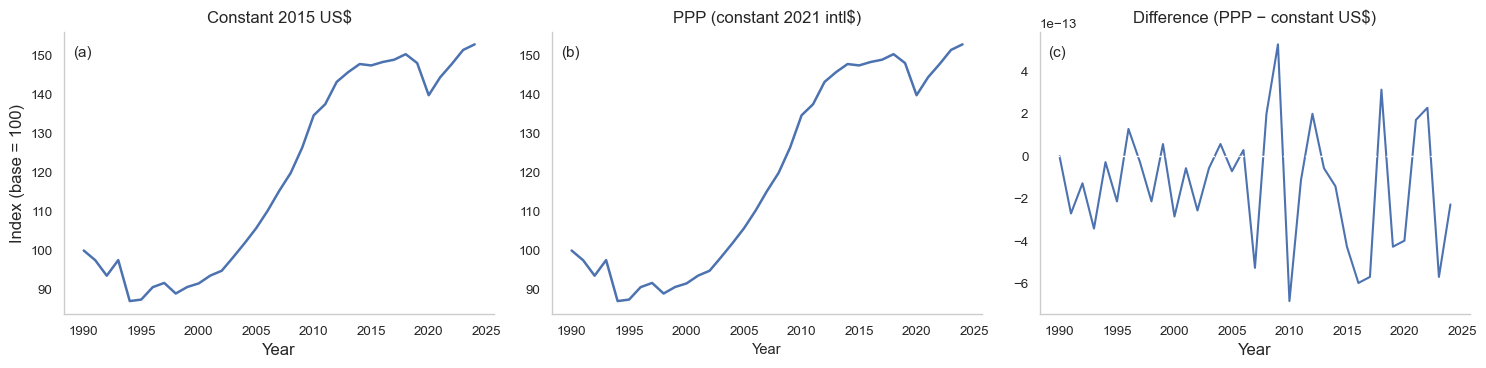

In [12]:
cols = ['NY.GDP.PCAP.KD', 'NY.GDP.PCAP.PP.KD']

df = eco_perform_clean[['Year'] + cols].copy()
df = df.dropna(subset=cols)
df = df.set_index('Year')

base_year = df.index.min()
indexed = df.div(df.loc[base_year]).mul(100)

diff = indexed['NY.GDP.PCAP.PP.KD'] - indexed['NY.GDP.PCAP.KD']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---- Panel (a): Constant USD ----
axes[0].plot(indexed.index, indexed['NY.GDP.PCAP.KD'], linewidth=1.8)
axes[0].set_title('Constant 2015 US$', fontsize=12)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Index (base = 100)', fontsize=12)

# ---- Panel (b): PPP ----
axes[1].plot(indexed.index, indexed['NY.GDP.PCAP.PP.KD'], linewidth=1.8)
axes[1].set_title('PPP (constant 2021 intl$)', fontsize=12)
axes[1].set_xlabel('Year')

# ---- Panel (c): Difference ----
axes[2].plot(diff.index, diff, linewidth=1.5)
axes[2].axhline(0, linestyle='--', linewidth=1)
axes[2].set_title('Difference (PPP − constant US$)', fontsize=12)
axes[2].set_xlabel('Year', fontsize=12)

# ---- Remove grids & top/right spines ----
for ax in axes:
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ---- Panel labels ----
labels = ['(a)', '(b)', '(c)']
for ax, label in zip(axes, labels):
    ax.text(0.02, 0.95, label, transform=ax.transAxes,
            fontsize=11, va='top')

# # ---- Overall title ----
# fig.suptitle(
#     f'Zambia: GDP per capita growth paths under alternative price concepts ({base_year} = 100)',
#     fontsize=12
# )

plt.tight_layout(rect=[0, 0, 1, 0.95])
# save figure
fig.savefig(
    "../figures/eco_performance/PPP_Constant_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

Because growth rates are serially correlated, a simple t-test overstates significance.

In [13]:
import statsmodels.api as sm

y = diff
X = sm.add_constant(np.ones(len(y)))  # intercept-only model

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':2})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 11 Mar 2026   Prob (F-statistic):                nan
Time:                        00:32:31   Log-Likelihood:                 962.15
No. Observations:                  35   AIC:                            -1922.
Df Residuals:                      34   BIC:                            -1921.
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.364e-13    3.6e-14     -3.790      0.0

estimated an intercept-only regression with HAC (Newey–West) standard errors.
$g_t^{P P P}-g_t^{U S D}=\alpha+\varepsilon_t$

| Quantity | Value                                | Interpretation |
| :--- |:-------------------------------------| :--- |
| Number of observations | 35                                   | Annual data, overlap period |
| Mean difference (coef) | -1.36 $\boldsymbol{\times} 10^{-13}$ | Essentially zero |
| Standard error | 3.6 $\times 10^{-14}$                | Extremely small |
| 95% CI | [-2.07e-13, -6.59e-14]               | Tight around zero |
| Durbin-Watson | 2.29                                 | No residual autocorrelation |
| Covariance | HAC (2 lags)                         | Robust inference |

After indexing both series to a common base year, the average difference in annual GDP per capita growth rates between PPP-adjusted and constant-dollar measures is economically negligible. A formal test confirms that any measured difference is on the order of numerical precision and does not represent a meaningful divergence in growth trends.

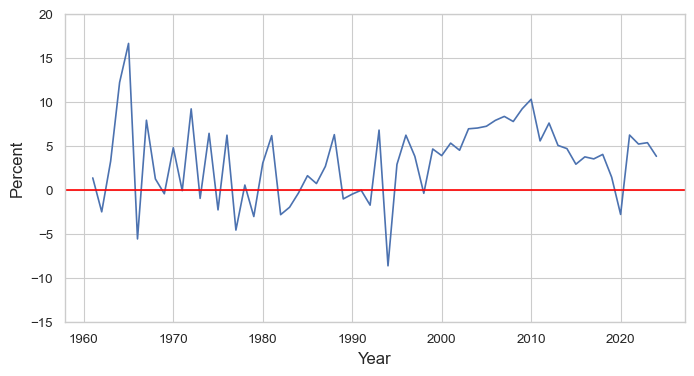

In [14]:
df = eco_perform_clean.dropna(subset=['NY.GDP.MKTP.KD.ZG'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Year'], df['NY.GDP.MKTP.KD.ZG'])
ax.axhline(0, color='red')
# ax.set_title('GDP growth (annual %)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent', fontsize=12)

ax.set_ylim(-15, 20)

fig.savefig(
    "../figures/eco_performance/GDP_growth.pdf",
    format="pdf",
    bbox_inches="tight"
)

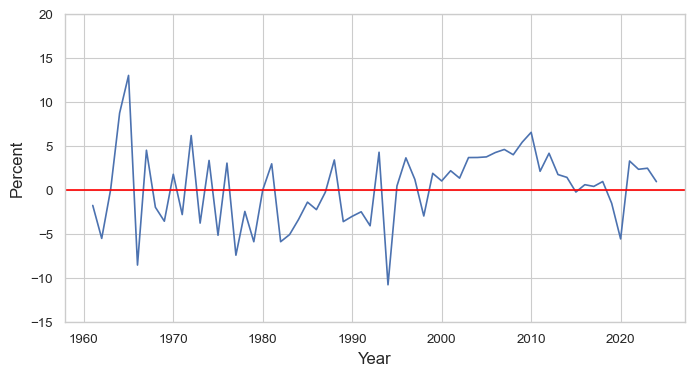

In [15]:
df = eco_perform_clean.dropna(subset=['NY.GDP.PCAP.KD.ZG'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['Year'], df['NY.GDP.PCAP.KD.ZG'])
# ax.set_title('GDP per capita growth (annual %)')
ax.axhline(0, color='red')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent', fontsize=12)

ax.set_ylim(-15, 20)

fig.savefig(
    "../figures/eco_performance/GDPPC_growth.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [16]:
df = eco_perform_clean[['Year', 'NY.GDP.PCAP.KD']].dropna()
df = df.set_index('Year')

# define decade
df['decade'] = (df.index // 10) * 10

decadal_growth = []

for dec, group in df.groupby('decade'):
    if len(group) > 1:
        start = group.iloc[0]['NY.GDP.PCAP.KD']
        end = group.iloc[-1]['NY.GDP.PCAP.KD']
        n = len(group) - 1
        g = (end / start) ** (1/n) - 1
        decadal_growth.append((dec, g * 100))

decadal_growth = pd.DataFrame(decadal_growth, columns=['Decade', 'Growth'])

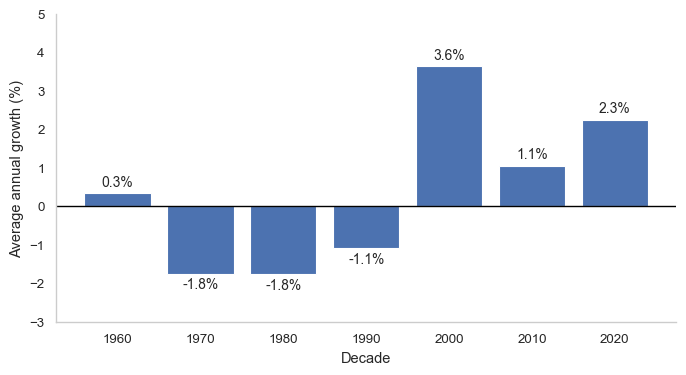

In [17]:
fig, ax = plt.subplots(figsize=(8,4))

ax.bar(decadal_growth['Decade'].astype(str),
       decadal_growth['Growth'])

ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Decade')
ax.set_ylabel('Average annual growth (%)')

# show percentage on each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(p.get_x() + p.get_width() / 2, height + 0.1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)
    else:
        ax.text(p.get_x() + p.get_width() / 2, height - 0.1,
                f'{height:.1f}%', ha='center', va='top', fontsize=10)

ax.set_ylim(-3, 5)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/eco_performance/GDPPC_growth_decade.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Unemployment

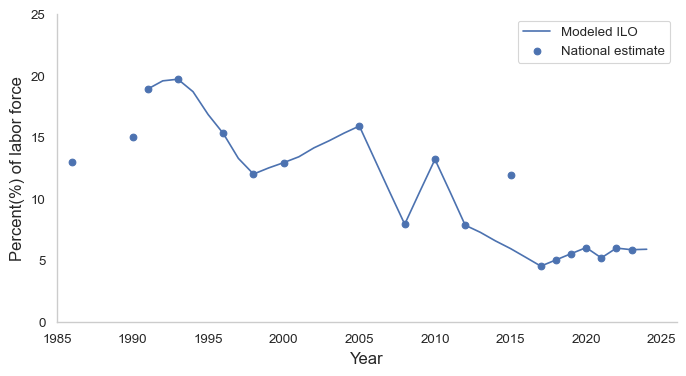

In [18]:
df = eco_perform_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df.index, df['SL.UEM.TOTL.ZS'], label='Modeled ILO')
ax.scatter(df.index, df['SL.UEM.TOTL.NE.ZS'], label='National estimate')

# ax.set_title('Unemployment rate (% of labor force)')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent(%) of labor force', fontsize=12)
ax.set_ylim(0, 25)
ax.set_xlim(1985, 2026)

ax.legend()

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/eco_performance/UEM_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

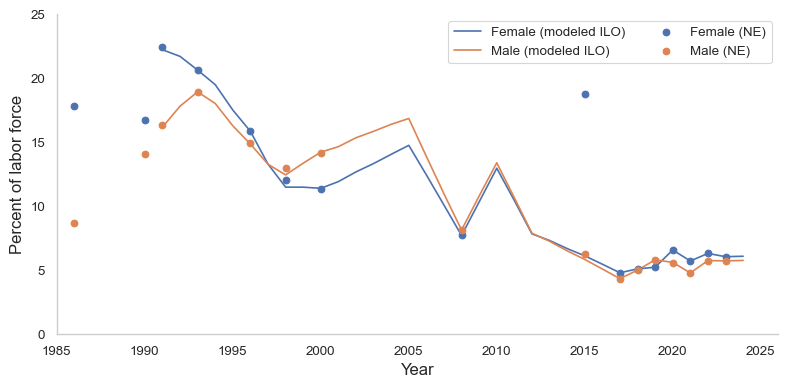

In [19]:
df = eco_perform_clean.set_index('Year')

fig, ax = plt.subplots(figsize=(8, 4))

# ---- Modeled ILO (lines) ----
ax.plot(df.index, df['SL.UEM.TOTL.FE.ZS'], label='Female (modeled ILO)')
ax.plot(df.index, df['SL.UEM.TOTL.MA.ZS'], label='Male (modeled ILO)')

# ---- National estimates (dots) ----
ax.scatter(df.index, df['SL.UEM.TOTL.FE.NE.ZS'],
           label='Female (NE)', zorder=3)
ax.scatter(df.index, df['SL.UEM.TOTL.MA.NE.ZS'],
           label='Male (NE)', zorder=3)

# ---- Labels ----
# ax.set_title('Unemployment rate by gender')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of labor force', fontsize=12)
ax.set_ylim(0, 25)
ax.set_xlim(1985, 2026)

# ---- Style ----
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(ncol=2)  # compact legend

plt.tight_layout()
fig.savefig(
    "../figures/eco_performance/UEM_gender.pdf",
    format="pdf",
    bbox_inches="tight"
)

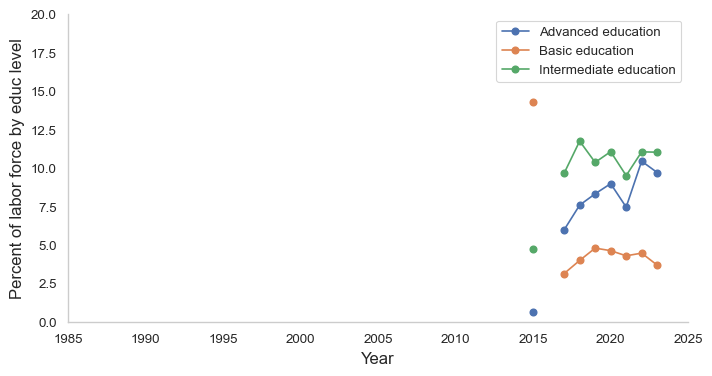

In [20]:
fig, ax = plt.subplots(figsize=(8,4))

df = eco_perform_clean.set_index('Year')

ax.plot(df.index, df['SL.UEM.ADVN.ZS'], marker='o', label='Advanced education')
ax.plot(df.index, df['SL.UEM.BASC.ZS'], marker='o', label='Basic education')
ax.plot(df.index, df['SL.UEM.INTM.ZS'], marker='o', label='Intermediate education')

# ax.set_title('Unemployment rate by education level')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percent of labor force by educ level', fontsize=12)
ax.legend()

# styling
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlim(1985, 2025)
ax.set_ylim(0, 20)

fig.savefig(
    "../figures/eco_performance/UEM_education.pdf",
    format="pdf",
    bbox_inches="tight"
)